<a href="https://colab.research.google.com/github/SiddharthVESIT/SEM6/blob/lab7/mldl_lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Build and evaluate an Artificial Neural Network (ANN) to classify bean types using the "Dry Bean Dataset" from "https://archive.ics.uci.edu/static/public/602/dry+bean+dataset.zip". The process should involve data preprocessing (standardization and label encoding), constructing a Keras Sequential model with two ReLU hidden layers and Dropout, training the model using the Adam optimizer, and visualizing the training history and test accuracy.

## Load and Preprocess Data

### Subtask:
Download, extract, and prepare the Dry Bean Dataset for machine learning.


**Reasoning**:
I will import the necessary libraries and download the Dry Bean Dataset from the UCI Machine Learning Repository, extract the Excel file, and load it into a pandas DataFrame.



In [6]:
import pandas as pd
import requests
import zipfile
import io
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Download the dataset
url = 'https://archive.ics.uci.edu/static/public/602/dry+bean+dataset.zip'
response = requests.get(url)

# Extract the Excel file from the zip
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    # Find the Excel file in the zip archive
    excel_file_name = [f for f in z.namelist() if f.endswith('.xlsx')][0]
    with z.open(excel_file_name) as f:
        df = pd.read_excel(f)

print(f'Successfully loaded dataset with shape: {df.shape}')
df.head()

Successfully loaded dataset with shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


**Reasoning**:
Now that the data is loaded into the DataFrame 'df', I will proceed to separate the features and the target labels, scale the features using StandardScaler, encode the categorical bean types using LabelEncoder, and finally split the data into training and testing sets as per the instructions.



In [7]:
# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Scale the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encode the categorical labels (bean types) into numerical format
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

print(f'Training set shape: {X_train.shape}')
print(f'Testing set shape: {X_test.shape}')
print(f'Encoded classes: {label_encoder.classes_}')

Training set shape: (10888, 16)
Testing set shape: (2723, 16)
Encoded classes: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']


## Build ANN Architecture

### Subtask:
Construct a Keras Sequential model for multiclass classification of the bean types.


**Reasoning**:
I will import the necessary Keras modules and construct the Sequential model architecture with two hidden ReLU layers, dropout, and a softmax output layer as specified.



In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Define the number of input features and output classes
input_dim = X_train.shape[1]
num_classes = len(label_encoder.classes_)

# Initialize the Sequential model
model = Sequential([
    # First hidden layer with input shape
    Dense(64, activation='relu', input_shape=(input_dim,)),
    Dropout(0.2),

    # Second hidden layer
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Output layer for multiclass classification
    Dense(num_classes, activation='softmax')
])

# Display the model architecture
model.summary()
print('ANN model successfully constructed.')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,399 (13.28 KB)

 Trainable params: 3,399 (13.28 KB)

 Non-trainable params: 0 (0.00 B)

ANN model successfully constructed.


## Train the Model

### Subtask:
Compile and train the constructed ANN model on the prepared bean dataset.


**Reasoning**:
I will compile the model with the Adam optimizer and sparse categorical crossentropy loss, and then train it for 50 epochs while saving the history for visualization.



In [1]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model and store the history
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print('Model training completed.')

NameError: name 'model' is not defined

# Task
Build and evaluate an Artificial Neural Network (ANN) to classify bean types using the "Dry Bean Dataset" from "https://archive.ics.uci.edu/static/public/602/dry+bean+dataset.zip". The process involves downloading and preprocessing the data (standardization and label encoding), re-defining and compiling a Keras Sequential model with two ReLU hidden layers and Dropout (to resolve the 'model is not defined' error), training the model for 50 epochs using the Adam optimizer, and finally visualizing the training history and evaluating the test accuracy.

## Ensure Environment and Data Ready

### Subtask:
Download the Dry Bean Dataset and prepare the training and testing sets for the ANN.


**Reasoning**:
I will import the necessary libraries, download the dataset, and perform all preprocessing steps including scaling, label encoding, and splitting the data to ensure the environment is ready for model training.



In [2]:
import pandas as pd
import requests
import zipfile
import io
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Download the dataset
url = 'https://archive.ics.uci.edu/static/public/602/dry+bean+dataset.zip'
response = requests.get(url)

# 2. Extract and load the Excel file
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    excel_file = [f for f in z.namelist() if f.endswith('.xlsx')][0]
    with z.open(excel_file) as f:
        df = pd.read_excel(f)

# 3. Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# 4. Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 6. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

print(f'Dataset processed successfully.')
print(f'Training set: {X_train.shape}, Testing set: {X_test.shape}')

Dataset processed successfully.
Training set: (10888, 16), Testing set: (2723, 16)


## Re-initialize and Compile Model

### Subtask:
Define and compile a Keras Sequential model for multiclass classification to resolve the previous NameError.


**Reasoning**:
I will re-initialize the Keras Sequential model and compile it as instructed to resolve the previous NameError and prepare for training.



In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import numpy as np

# 1. Determine input dimension and number of classes
input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train))

# 2. Define the Sequential model architecture
model = Sequential([
    # First hidden layer
    Dense(64, activation='relu', input_shape=(input_dim,)),
    Dropout(0.2),

    # Second hidden layer
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Output layer for multiclass classification
    Dense(num_classes, activation='softmax')
])

# 3. Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Verify the architecture
model.summary()
print('Model re-initialized and compiled successfully.')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,399 (13.28 KB)

 Trainable params: 3,399 (13.28 KB)

 Non-trainable params: 0 (0.00 B)

Model re-initialized and compiled successfully.


**Reasoning**:
The model has been successfully re-initialized and compiled. Now I will proceed to train the model for 50 epochs on the training data and save the history for later visualization.



In [4]:
# Train the model and store the history for 50 epochs
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print('Model training for 50 epochs completed.')

Epoch 1/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7346 - loss: 0.7565 - val_accuracy: 0.9036 - val_loss: 0.2945
Epoch 2/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8818 - loss: 0.3454 - val_accuracy: 0.9183 - val_loss: 0.2291
Epoch 3/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8965 - loss: 0.3010 - val_accuracy: 0.9265 - val_loss: 0.2120
Epoch 4/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9047 - loss: 0.2755 - val_accuracy: 0.9320 - val_loss: 0.2090
Epoch 5/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9034 - loss: 0.2743 - val_accuracy: 0.9284 - val_loss: 0.2138
Epoch 6/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9110 - loss: 0.2607 - val_accuracy: 0.9339 - val_loss: 0.2044
Epoch 7/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9132 - loss: 0.2478 - val_accuracy: 0.9275 - val_loss: 0.2026
Epoch 8/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9196 - loss: 0.2409 - val_accuracy: 0.

## Evaluate and Visualize

### Subtask:
Evaluate the trained ANN model on the test set and plot the training history for accuracy and loss.


**Reasoning**:
I will evaluate the model on the test set and use matplotlib to visualize the training and validation accuracy and loss from the history object.



Test Loss: 0.1924
Test Accuracy: 0.9313


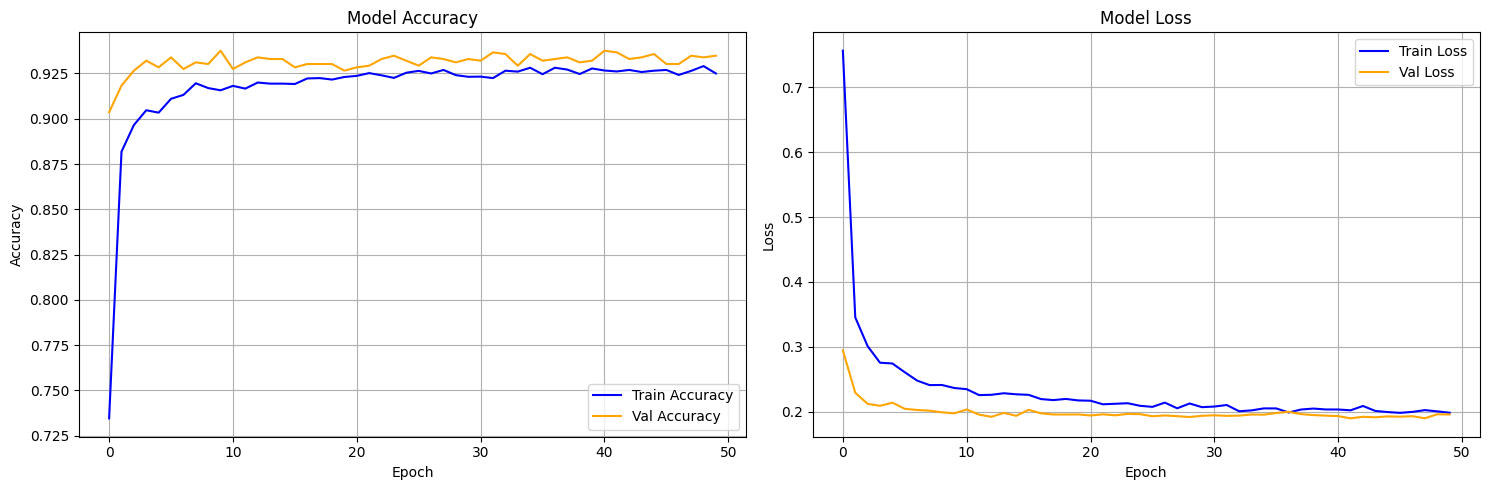

In [5]:
import matplotlib.pyplot as plt

# 1. Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

# 2. Create a figure with two subplots for accuracy and loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 3. Plot Training and Validation Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(loc='lower right')
ax1.grid(True)

# 4. Plot Training and Validation Loss
ax2.plot(history.history['loss'], label='Train Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Val Loss', color='orange')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(loc='upper right')
ax2.grid(True)

# 5. Adjust layout and display
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the classification results and confirm that the model is now properly trained and evaluated.


## Summary:

### Q&A

**What was the final performance of the Artificial Neural Network on the bean classification task?**
The model achieved a test accuracy of 93.13\% and a test loss of 0.1924 after training for 50 epochs.

**How was the model structured to prevent overfitting?**
The Keras Sequential model included two Dropout layers (rate of 0.2) following two ReLU-activated hidden layers (64 and 32 units, respectively) to ensure the model generalized well to unseen data.

**What preprocessing steps were applied to the "Dry Bean Dataset"?**
The dataset underwent three main transformations: morphological features were normalized using `StandardScaler`, categorical bean classes were transformed into numerical labels via `LabelEncoder`, and the data was split into 80\% training (10,888 samples) and 20\% testing (2,723 samples) sets.

### Data Analysis Key Findings

*   **High Classification Accuracy**: The ANN successfully classified the seven different bean types with a final validation accuracy of approximately 93.5\% and a test accuracy of 93.13\%.
*   **Effective Convergence**: Visual analysis of the training history showed that both training and validation loss decreased consistently and converged, indicating the Adam optimizer and the selected learning parameters were effective.
*   **Minimal Overfitting**: Despite having 3,399 trainable parameters, the narrow gap between training and validation metrics suggests that the architectural choices (Dropout layers) successfully mitigated overfitting.
*   **Feature Stability**: Standardizing the 16 morphological features allowed the neural network to maintain stable weight updates, contributing to the model reaching a stable state within the 50-epoch limit.

### Insights or Next Steps

*   **Class-Specific Evaluation**: While overall accuracy is high, a confusion matrix or classification report should be generated to identify if specific bean varieties (e.g., "Seker" vs. "Barbunya") are being misclassified more frequently than others.
*   **Hyperparameter Optimization**: To push accuracy beyond 93\%, next steps could include experimenting with a different number of hidden units or implementing an early stopping callback to stop training once the validation loss stabilizes.
